###  Installation de l'environnement

In [1]:
#%pip install -r requirements.txt

### Connexion à la DB DuckDB

In [2]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

### Connexion à la DB / Import des Data


In [3]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [4]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 4 tables in the database:

1. all_events
2. loaded_files
3. user_events
4. user_segments_kmeans


### Import de la table DuckDB

In [5]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "user_events"
TABLE_SEGMENTS = "user_segments"
SAMPLE_USER_PERCENT = 0.2
BATCH_SIZE = 1000 

In [6]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ all_events           │
│ loaded_files         │
│ user_events          │
│ user_segments_kmeans │
└──────────────────────┘



In [7]:
# Examine the all_events table
print(f"First 10 rows of {TABLE_EVENTS} table:")
user_events = con.sql(f"""
    SELECT * FROM {TABLE_EVENTS} LIMIT 5000
""")
user_events.show()
user_events_df = user_events.df()


First 10 rows of user_events table:
┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬─────────────┬───────────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │ total_spent │    avg_basket     │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │                                                                                                      category_embedding                                                                                                       │
│  varchar  │    int64     │   double    │     double      │         double          │   d

In [8]:
user_events_df["category_embedding"].isna().value_counts()

category_embedding
False    4905
True       95
Name: count, dtype: int64

In [9]:
user_events_df = user_events_df.dropna(subset=["category_embedding"])

In [10]:
user_events_df["category_embedding"].isna().value_counts()

category_embedding
False    4905
Name: count, dtype: int64

### Normalisation et Standardisation des données

In [11]:
from sklearn.preprocessing import StandardScaler

numeric_features = user_events_df.drop(
    columns=["last_event_time", "category_embedding"]
)

num_scaler = StandardScaler()
X_num_scaled = num_scaler.fit_transform(numeric_features)


In [12]:
X_num_scaled.shape

(4905, 10)

In [13]:
X_num_scaled

array([[ 0.4069079 ,  0.12639461,  0.11660835, ..., -0.35617122,
        -0.40382283, -0.91786296],
       [-1.19230193,  0.77957106,  0.62554497, ...,  0.29043832,
         0.44561052, -1.04973133],
       [-1.28718908,  0.77179515,  0.73056364, ...,  0.0664494 ,
         0.16067401,  0.63818374],
       ...,
       [-0.41813143, -0.43347092, -0.41656334, ..., -0.35617122,
        -0.40382283,  2.0359884 ],
       [ 0.56508104, -0.39459137, -0.37617155, ..., -0.35617122,
        -0.40382283, -0.81236827],
       [-0.24207895, -0.06022724, -0.0691939 , ...,  0.12279881,
         0.23325218, -0.99698398]], shape=(4905, 10))

In [14]:
user_events_df["category_embedding"].shape

(4905,)

In [15]:
user_events_df.describe()

,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
count,4905.000000,4905.000000,4905.000000,4.905000e+03,4905.000000,4905.000000,4905,4905.000000,4905.000000,4905.000000
mean,66.745362,62.565341,1.151478,1.705492e+05,358.816628,83.715484,2020-01-19 16:01:02.990825,0.027541,0.022638,71.802243
min,10.000000,1.000000,0.000000,2.157895e+00,0.000000,0.000000,2019-10-01 05:52:55,0.000000,0.000000,30.000000
25%,16.000000,15.000000,0.000000,3.319915e+04,0.000000,0.000000,2019-12-26 07:37:34,0.000000,0.000000,41.000000
50%,31.000000,29.000000,0.000000,1.013845e+05,0.000000,0.000000,2020-02-02 00:34:29,0.000000,0.000000,58.000000
75%,68.000000,63.000000,1.000000,2.332813e+05,104.240000,64.350000,2020-02-19 16:13:30,0.013514,0.013333,96.000000
max,3674.000000,3646.000000,106.000000,1.426712e+06,79707.070000,2448.946667,2020-02-29 22:06:43,1.000000,0.500000,182.000000
std,128.615420,123.800136,4.169836,1.983510e+05,2016.803836,202.863960,NaN,0.077334,0.056065,37.920465


In [16]:
tmp_user_events_df = user_events_df.copy()
tmp_user_events_df.reset_index(drop=True, inplace=True)

In [17]:
# Stack the category_embedding column into a 2D array
category_embedding = np.vstack(tmp_user_events_df["category_embedding"].values)

# Check the shapes to ensure compatibility
print(f"Shape of X_num_scaled: {X_num_scaled.shape}")
print(f"Shape of category_embedding: {category_embedding.shape}")

# Concatenate the two arrays horizontally
X_combined = np.hstack([X_num_scaled, category_embedding])

# Verify the shape of the combined array
print(f"Shape of X_combined: {X_combined.shape}")

Shape of X_num_scaled: (4905, 10)
Shape of category_embedding: (4905, 10)
Shape of X_combined: (4905, 20)


In [18]:
import numpy as np

category_embedding = np.vstack(user_events_df["category_embedding"].values)
emb_scaler = StandardScaler()
X_emb_scaled = emb_scaler.fit_transform(category_embedding)


In [19]:
# Replace for Using category embeddings
#X_final = np.hstack([X_num_scaled, X_emb_scaled])
X_final = X_num_scaled

### Choix du Nombre de Clusters, Analyse du Coude et Analyse de la struture des clusters

Analyse du coude pour déterminer le nombre optimal de clusters...


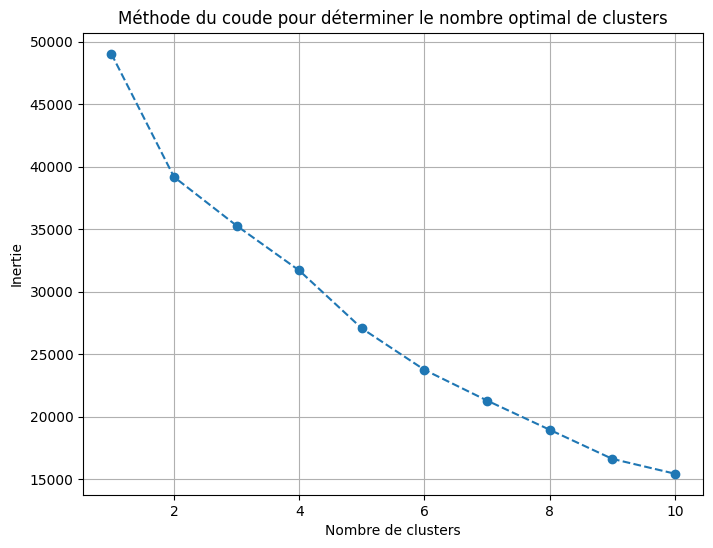

In [20]:

# Analyse du Coude (Elbow Method)
print("Analyse du coude pour déterminer le nombre optimal de clusters...")

inertia = []
cluster_range = range(1, 11)  # Test cluster counts from 1 to 10

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_final)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, inertia, marker='o', linestyle='--')
plt.title("Méthode du coude pour déterminer le nombre optimal de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid(True)
plt.show()

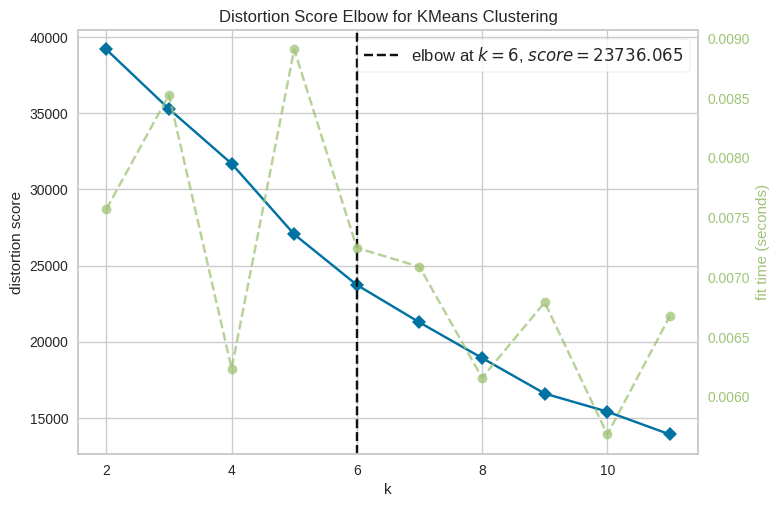

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer,SilhouetteVisualizer
# Elbow Visualizer 
km = KMeans(random_state=42)
visualizer = KElbowVisualizer(km, k=(2,12))
 
visualizer.fit(X_final)     
visualizer.show()

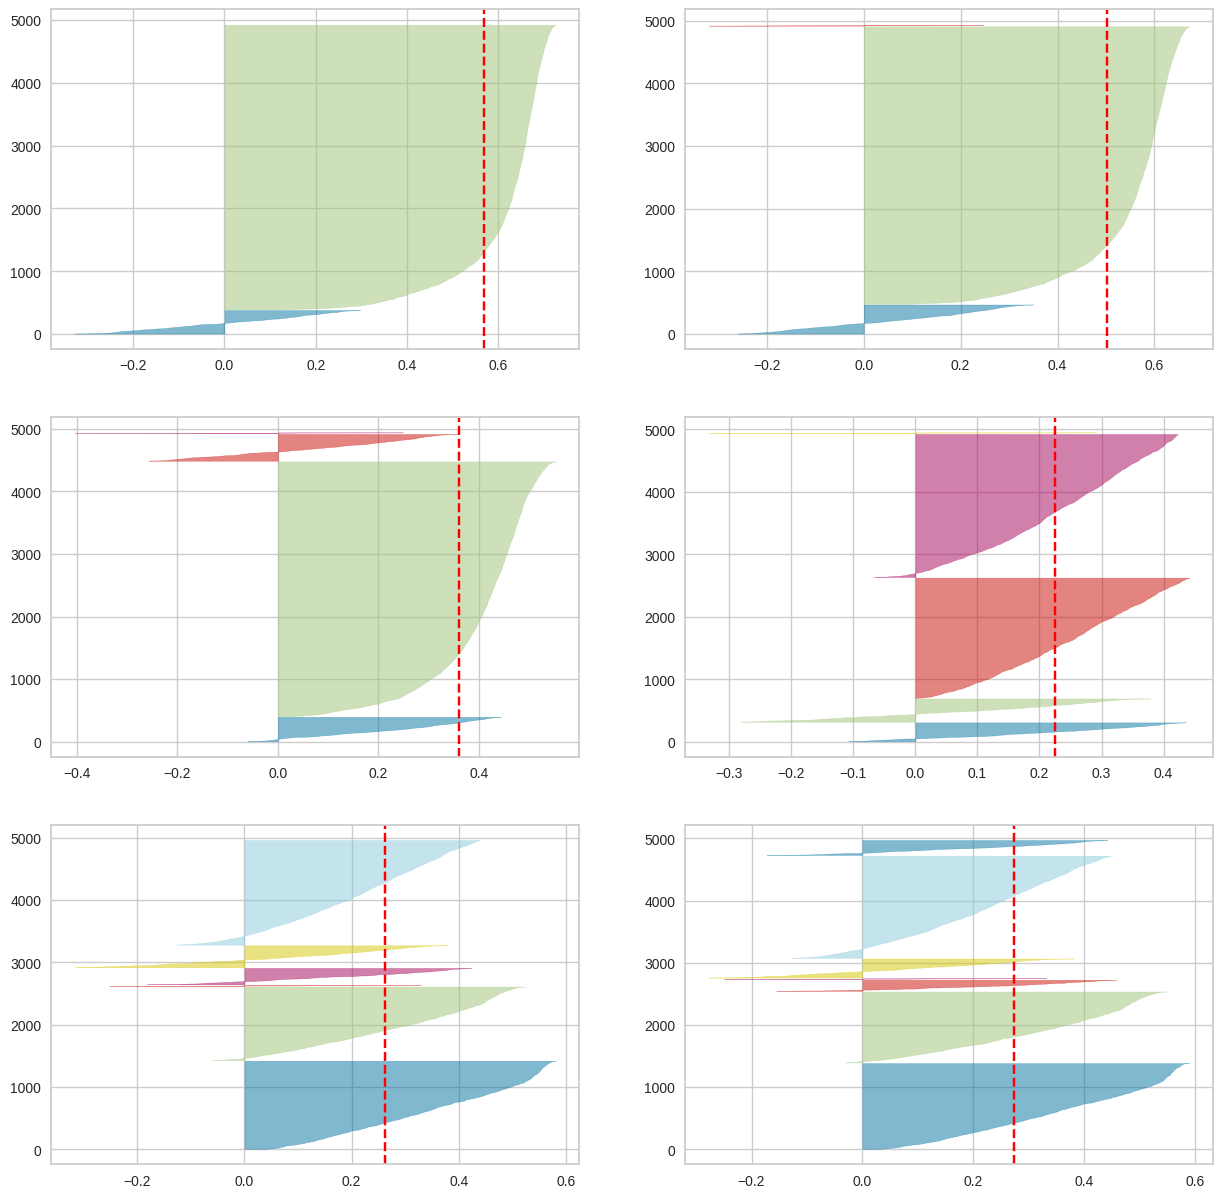

In [ ]:
# Ploting silhouette score for each cluster.
fig, ax = plt.subplots(3, 2, figsize=(15,15))
for i in [2, 3, 4, 5,6,7]:
    '''
    Create KMeans instances for different number of clusters
    '''
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)
    '''
    Create SilhouetteVisualizer instance with KMeans instance
    Fit the visualizer
    '''
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(X_final) 

### Analyse Silhouette, Calinski-Harabasz & Davies-Bouldin

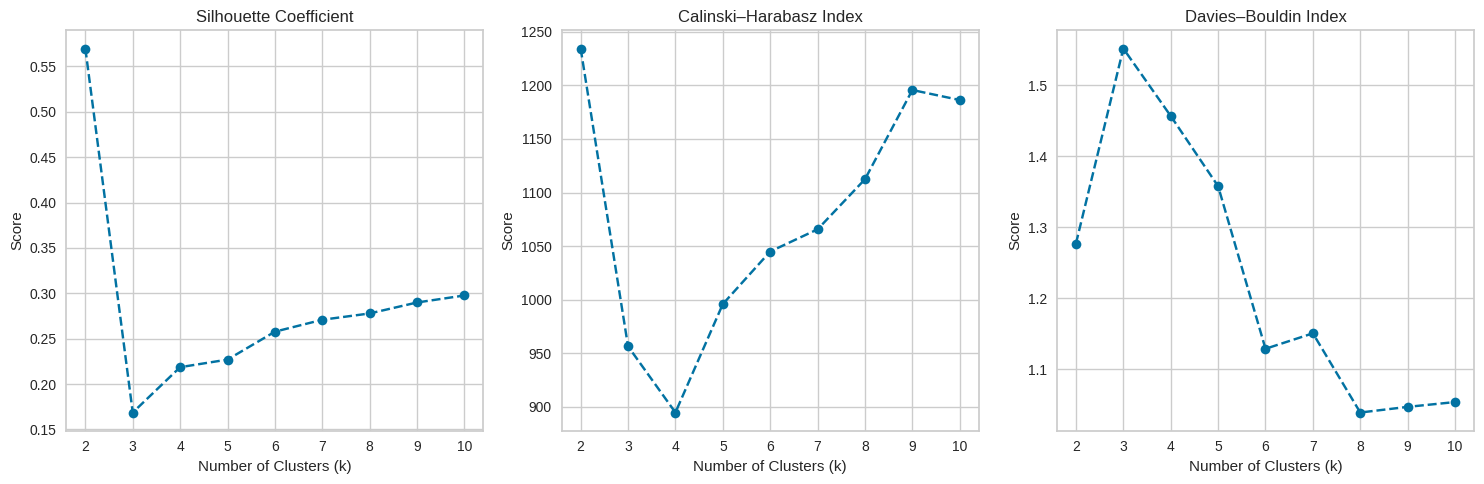

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Define the range of clusters to evaluate
ks = range(2, 11)

# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

# Evaluate clustering for each k
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X_final)
    labels = km.labels_
    
    # Compute the metrics
    silhouette_scores.append(silhouette_score(X_final, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_final, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_final, labels))

# Plot the metrics
plt.figure(figsize=(15, 5))

# Silhouette Coefficient
plt.subplot(1, 3, 1)
plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
plt.title("Silhouette Coefficient")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

# Calinski–Harabasz Index
plt.subplot(1, 3, 2)
plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
plt.title("Calinski–Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

# Davies–Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
plt.title("Davies–Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

### Fit et Plot KMeans

In [23]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.offline as py
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd


def kmeans_fit_and_plot_per_cluster(k, X_final, df):
    df_tmp = df.copy()
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_final)
    df_tmp["segment"] = clusters

    # --- Silhouette Analysis ---
    print("Silhouette Analysis...")
    silhouette_avg = silhouette_score(X_final, clusters)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(X_final, clusters)

    # Print silhouette score for each cluster
    for cluster in range(k):
        cluster_silhouette_avg = sample_silhouette_values[clusters == cluster].mean()
        print(f"Silhouette score for Cluster {cluster}: {cluster_silhouette_avg}")

    # Define consistent colors for clusters
    colormap = plt.colormaps.get_cmap("tab10")
    cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(k)]
    cluster_color_map = {i: cluster_colors[i] for i in range(k)}  # Map cluster index to color

    # --- Silhouette Plot ---
    plt.figure(figsize=(10, 8))
    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cluster_color_map[i]
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    plt.title(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {k}")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks(np.arange(-0.1, 1.1, 0.1))
    plt.show()

    # --- PCA Scatter Plot (2D) ---
    print("Visualisation du clustering (2D)...")
    pca = PCA(n_components=2)
    X_pca_2d = pca.fit_transform(X_final)

    plt.figure(figsize=(10, 8))
    for i in range(k):
        cluster_points = X_pca_2d[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=cluster_color_map[i], label=f"Cluster {i}", s=10)

    plt.title(f"Visualisation des clusters utilisateurs (PCA 2D)- K = {k}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- PCA Scatter Plot (3D) ---
    print("Visualisation du clustering (3D)...")
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_final)

    # Prepare data for Plotly
    traces = []
    for i in range(k):
        cluster_points = X_pca_3d[clusters == i]
        trace = go.Scatter3d(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            z=cluster_points[:, 2],
            mode='markers',
            marker=dict(
                size=8,
                color=cluster_color_map[i],  # Use consistent cluster color
                opacity=0.8
            ),
            name=f"Cluster {i}"
        )
        traces.append(trace)

    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Plot of Clusters"
    )
    fig = go.Figure(data=traces, layout=layout)
    py.iplot(fig, filename='3d-scatter-colorscale')

    return df_tmp

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_stats(df, segment_column="segment"):
    """
    Plots statistics, distributions, and boxplots for clusters in the DataFrame.

    Parameters:
    - df: DataFrame containing the clustering results and features.
    - segment_column: Name of the column containing cluster segments.

    Returns:
    - stats: A dictionary containing descriptive statistics for each cluster.
    """
    # Ensure the segment column exists
    if segment_column not in df.columns:
        raise ValueError(f"Column '{segment_column}' not found in the DataFrame.")

    # Number of individuals per cluster
    cluster_counts = df[segment_column].value_counts().sort_index()
    print("Number of individuals per cluster:")
    print(cluster_counts)

    # Plot the distribution of individuals per cluster
    plt.figure(figsize=(10, 6))
    cluster_counts.plot(kind="bar", color="skyblue", alpha=0.8)
    plt.title("Distribution of Individuals per Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Number of Individuals")
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    # Descriptive statistics for each cluster
    stats = {}
    for cluster in cluster_counts.index:
        cluster_data = df[df[segment_column] == cluster]
        cluster_stats = cluster_data.describe()
        stats[cluster] = cluster_stats
        print(f"\nDescriptive statistics for Cluster {cluster}:")
        print(cluster_stats)

    # Boxplots for each column grouped by cluster
    numeric_columns = df.select_dtypes(include=["number"]).columns
    numeric_columns = [col for col in numeric_columns if col != segment_column]

    for col in numeric_columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=segment_column, y=col, data=df, palette="Set3")
        plt.title(f"Boxplot of {col} by Cluster")
        plt.xlabel("Cluster")
        plt.ylabel(col)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()

    return stats

Silhouette Analysis...


For n_clusters = 6, the average silhouette_score is: 0.2577494809885097
Silhouette score for Cluster 0: 0.3628682550090877
Silhouette score for Cluster 1: 0.1972178517953442
Silhouette score for Cluster 2: 0.07097718281353865
Silhouette score for Cluster 3: 0.2946921506388754
Silhouette score for Cluster 4: 0.0963675863198042
Silhouette score for Cluster 5: 0.16003346029048598


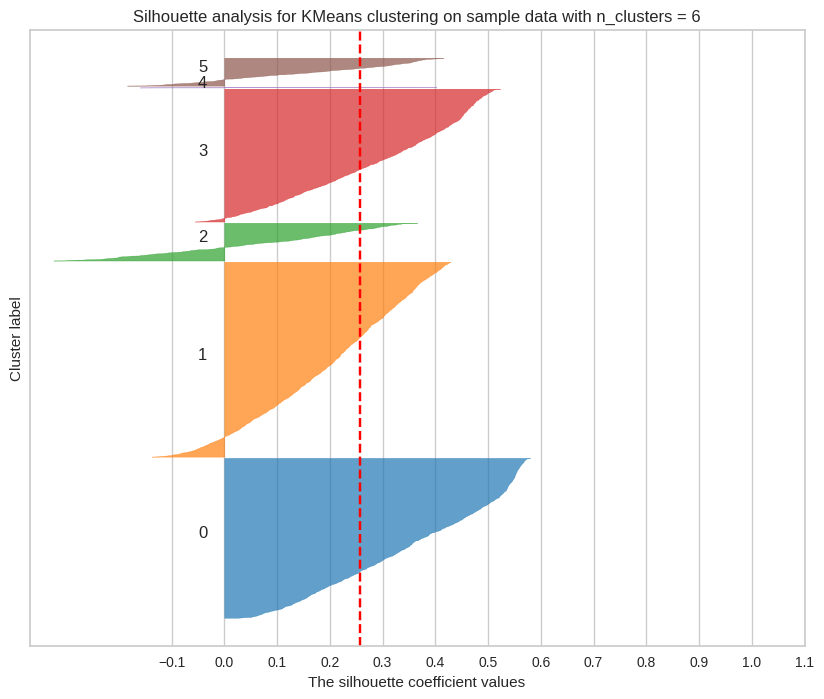

Visualisation du clustering (2D)...


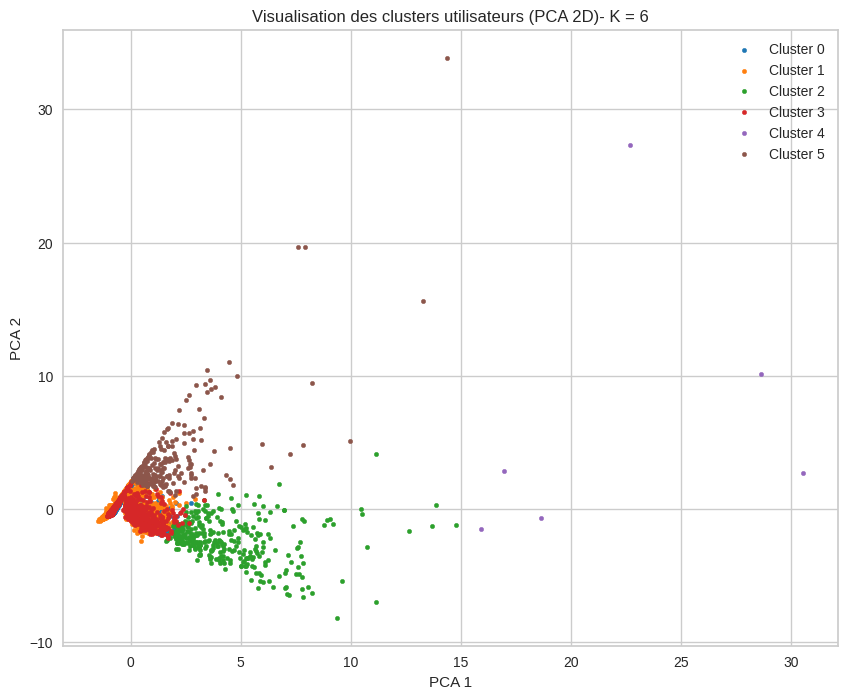

Visualisation du clustering (3D)...


In [25]:
N_CLUSTERS = 6

df_kmeans = kmeans_fit_and_plot_per_cluster(N_CLUSTERS, X_final, user_events_df)

In [26]:
df_kmeans["segment"].value_counts()

segment
1    1725
0    1415
3    1176
2     335
5     248
4       6
Name: count, dtype: int64

Number of individuals per cluster:
segment
0    1415
1    1725
2     335
3    1176
4       6
5     248
Name: count, dtype: int64


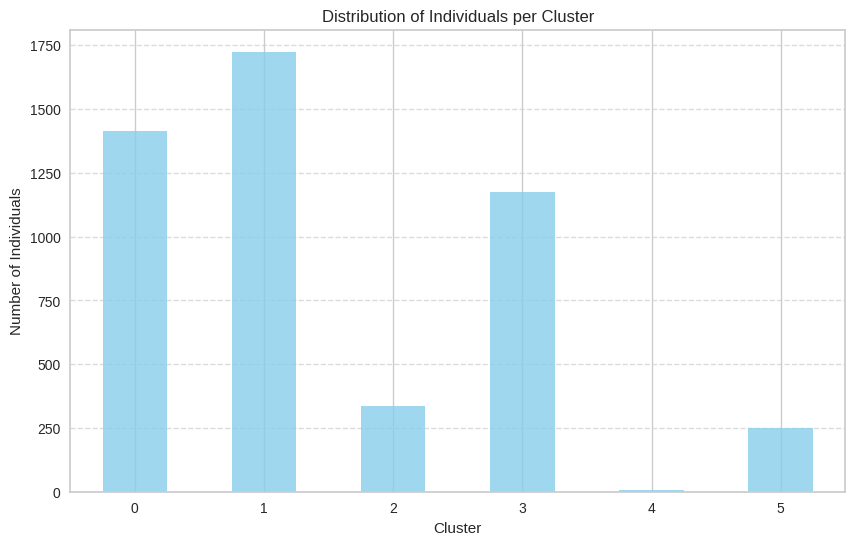


Descriptive statistics for Cluster 0:
       total_events  total_views  total_purchases  avg_time_between_events  \
count   1415.000000  1415.000000       1415.00000              1415.000000   
mean      46.716608    44.568905          0.39576             90952.262495   
min       10.000000     1.000000          0.00000                 2.157895   
25%       16.000000    15.000000          0.00000             16667.391667   
50%       30.000000    28.000000          0.00000             68892.956522   
75%       59.000000    56.000000          0.00000            135610.429201   
max      286.000000   272.000000          8.00000            466433.300000   
std       45.528838    44.033138          0.95232             91850.989040   

       total_spent   avg_basket             last_event_time  conversion_rate  \
count  1415.000000  1415.000000                        1415      1415.000000   
mean     76.074834    40.870830  2020-02-04 14:28:15.577385         0.010661   
min       0.000000

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




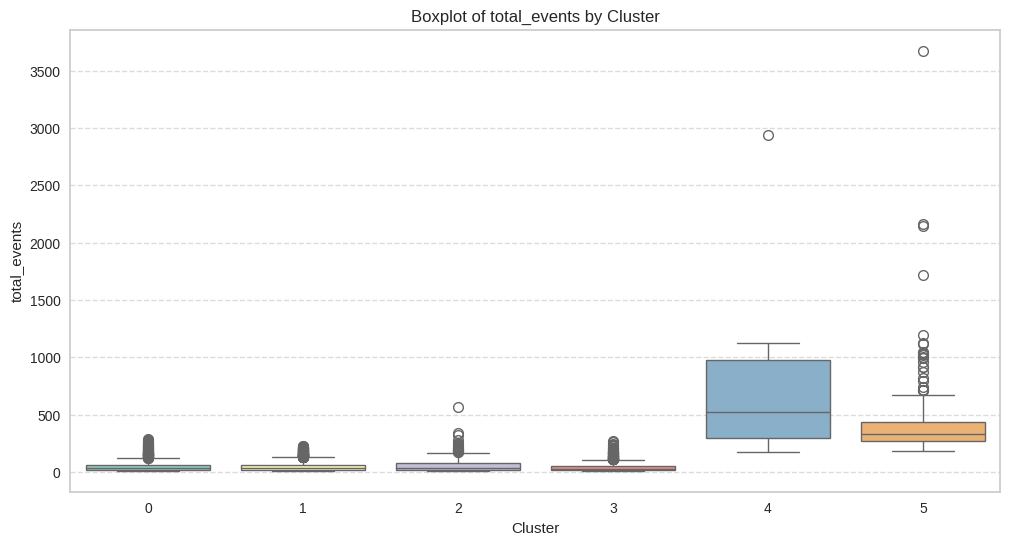

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




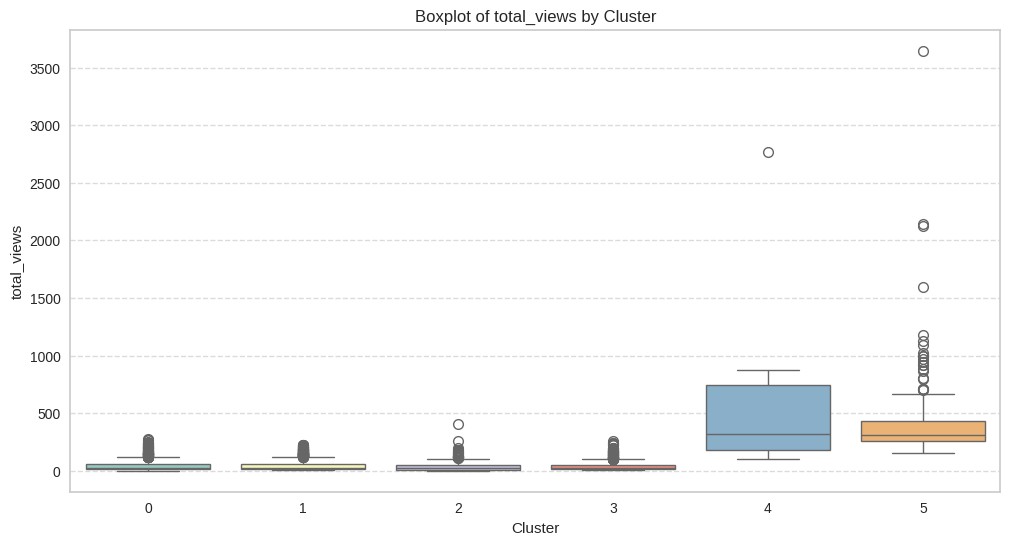

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




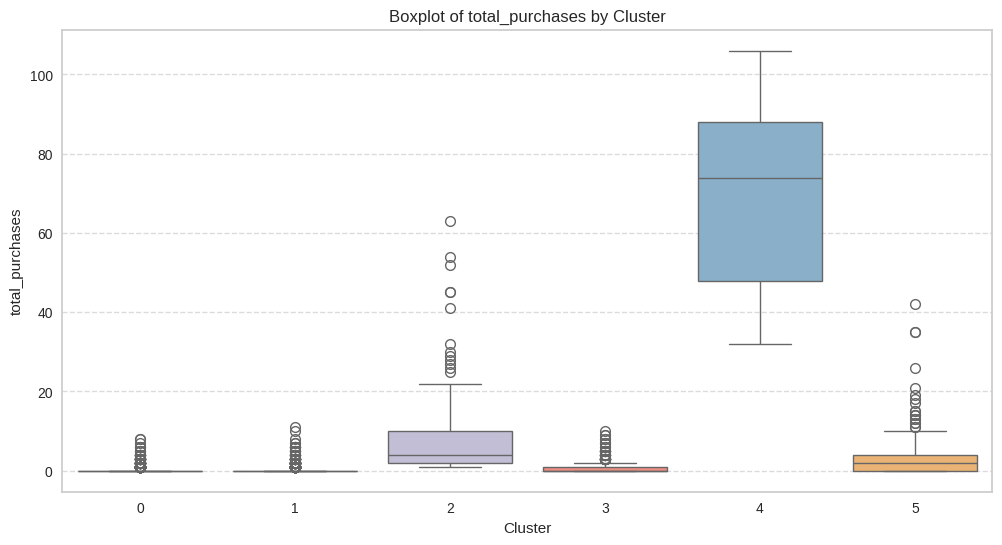

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




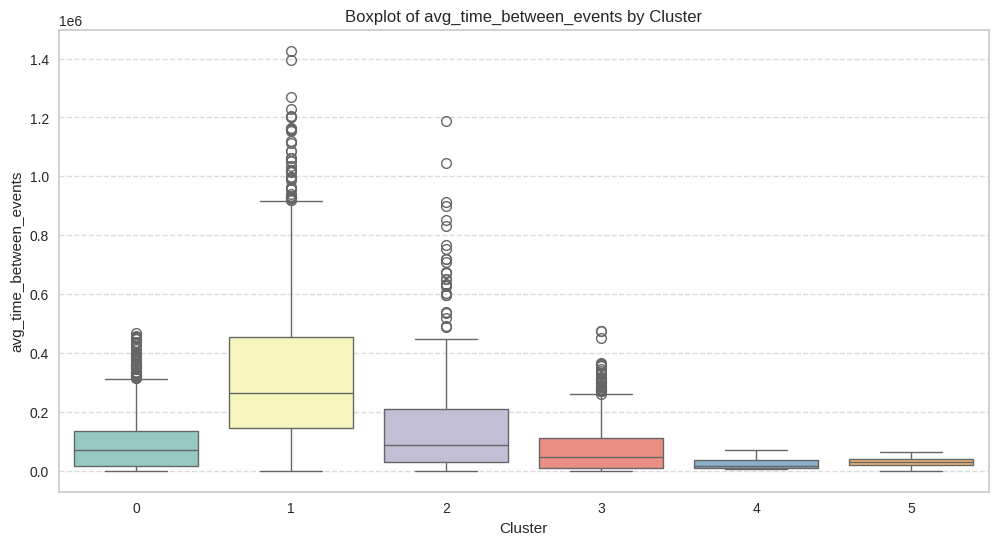

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




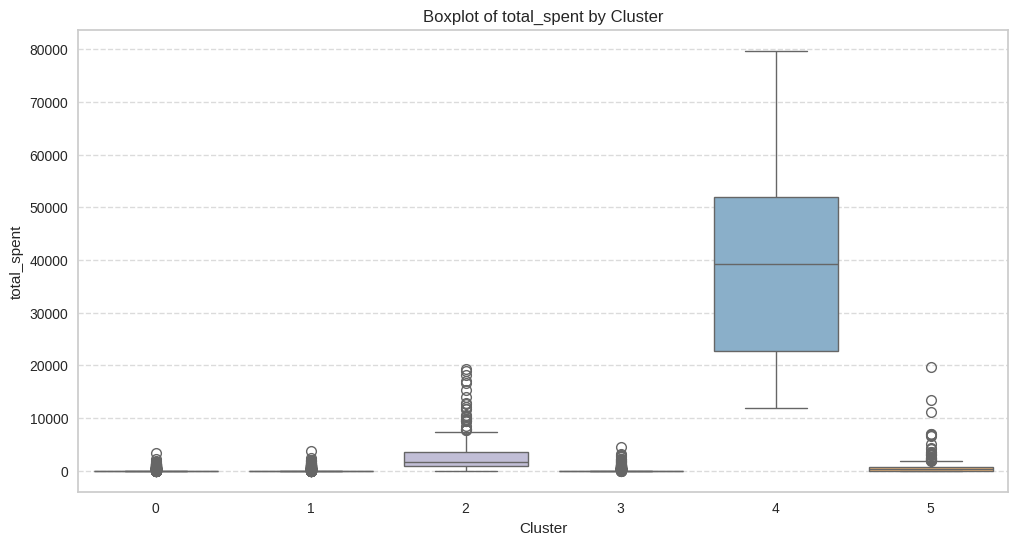

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




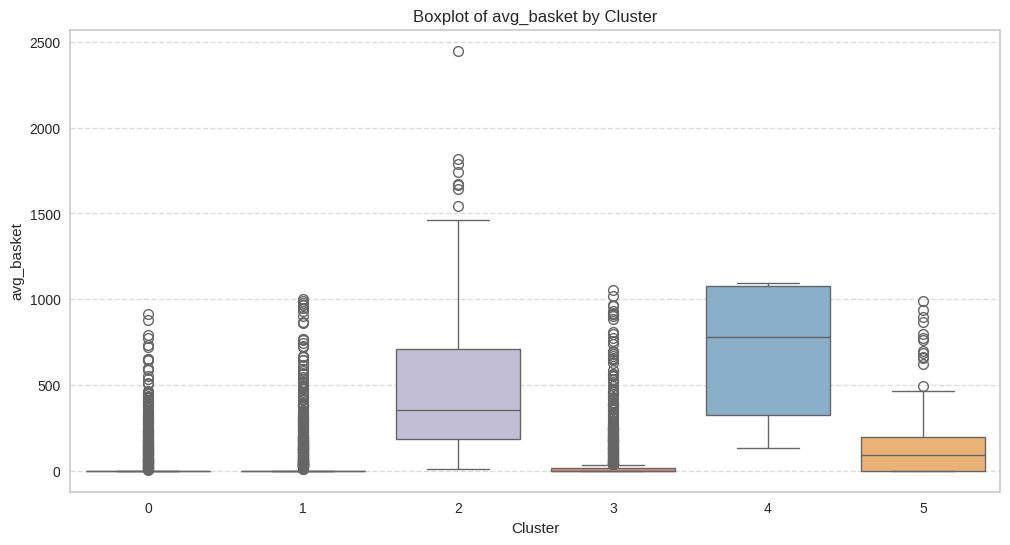

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




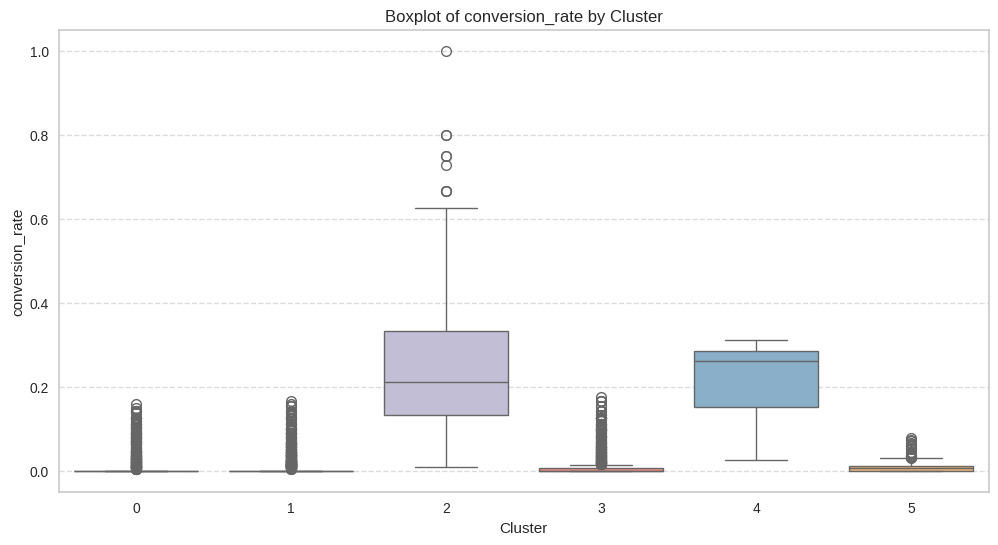

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




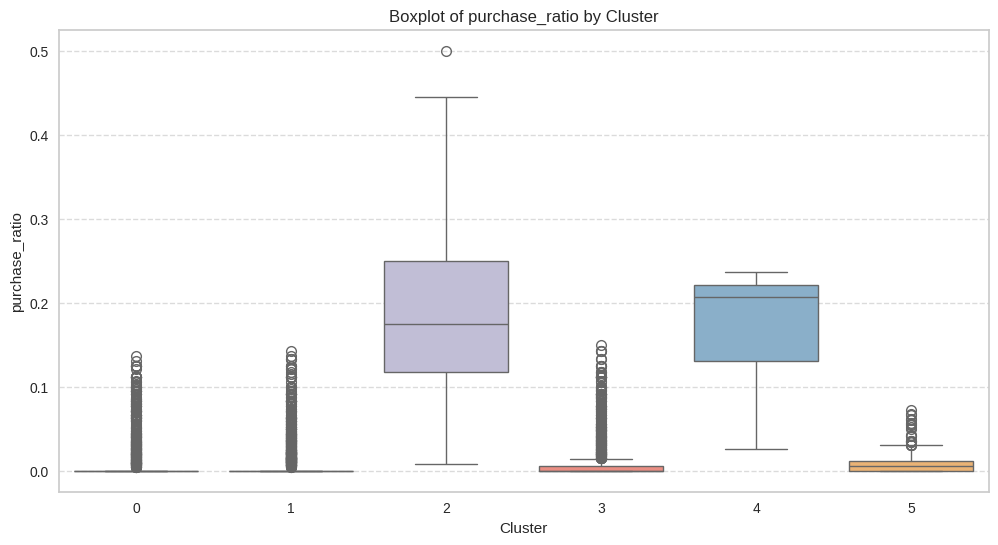

/tmp/ipykernel_101286/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




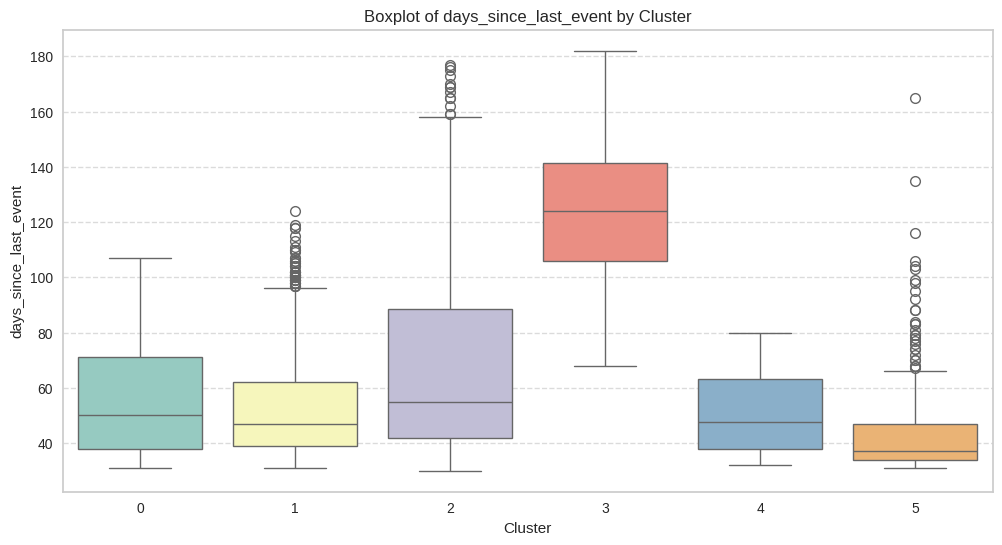

{0:        total_events  total_views  total_purchases  avg_time_between_events  \
 count   1415.000000  1415.000000       1415.00000              1415.000000   
 mean      46.716608    44.568905          0.39576             90952.262495   
 min       10.000000     1.000000          0.00000                 2.157895   
 25%       16.000000    15.000000          0.00000             16667.391667   
 50%       30.000000    28.000000          0.00000             68892.956522   
 75%       59.000000    56.000000          0.00000            135610.429201   
 max      286.000000   272.000000          8.00000            466433.300000   
 std       45.528838    44.033138          0.95232             91850.989040   
 
        total_spent   avg_basket             last_event_time  conversion_rate  \
 count  1415.000000  1415.000000                        1415      1415.000000   
 mean     76.074834    40.870830  2020-02-04 14:28:15.577385         0.010661   
 min       0.000000     0.000000         

In [27]:
plot_cluster_stats(df_kmeans, segment_column="segment")

### Sauvegarde du DataFrame en Table DuckDB

In [28]:
con.execute(f"DROP TABLE IF EXISTS {TABLE_SEGMENTS}_kmeans")

con.execute(f"""
CREATE TABLE {TABLE_SEGMENTS}_kmeans AS
SELECT * FROM df_kmeans
""")

print("Clustering sauvegardé avec succès !")


Clustering sauvegardé avec succès !


In [29]:
user_segments = con.sql(f"""
    SELECT * FROM {TABLE_SEGMENTS}_kmeans
""")
user_segments.show()

┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬─────────────┬───────────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │ total_spent │    avg_basket     │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │                                                                                                      category_embedding                                                                                                       │ segment │
│  varchar  │    int64     │   double    │     double      │         double          │   double    │      

In [30]:
user_segments.df()["segment"].value_counts()

segment
1    1725
0    1415
3    1176
2     335
5     248
4       6
Name: count, dtype: int64

In [31]:
# Fermeture de la connexion DuckDB
con.close()